   Appliances  lights       T1     RH_1       T2     RH_2       T3     RH_3
0          40       0  20.8900  35.4000  17.7600  39.1633  20.2900  36.9000
1          90      10  21.8900  53.1000  21.2900  45.3600  21.6333  49.2267
2          50       0  21.3900  35.5000  17.6333  40.5300  21.6667  35.2000
3          50       0  21.3900  41.0333  23.8900  34.8400  22.0333  36.9333
4          70       0  19.9633  35.1267  16.4633  40.1267  20.0000  36.4000
(1974, 8)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1974 entries, 0 to 1973
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Appliances  1974 non-null   int64  
 1   lights      1974 non-null   int64  
 2   T1          1974 non-null   float64
 3   RH_1        1974 non-null   float64
 4   T2          1974 non-null   float64
 5   RH_2        1974 non-null   float64
 6   T3          1974 non-null   float64
 7   RH_3        1974 non-null   float64
dtypes: float64(6)

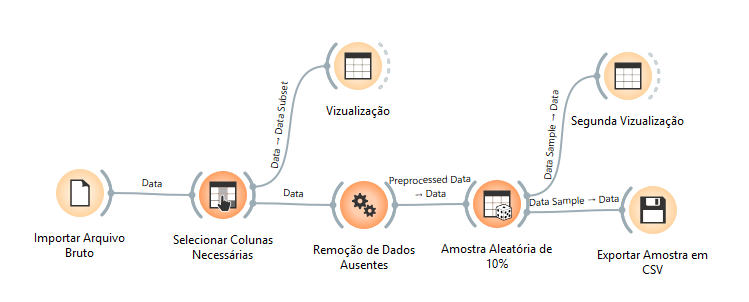

In [2]:
# Dataset 1 — Appliances Energy Prediction (UCI)

# 1.Carregar a base
import pandas as pd
df = pd.read_csv("/content/dataset1.csv")
print(df.head())
print(df.shape)
df.info()
print(df.describe())

# 2.Renomear as colunas
df = df.rename(columns={
    "Appliances": "Consumo_Eletrodomesticos",
    "lights": "Iluminacao",
    "RH_1": "Umidade_1",
    "RH_2": "Umidade_2",
    "RH_3": "Umidade_3"
})

# 3.Determinar o maior consumo de eletrodomésticos
maior_consumo = df["Consumo_Eletrodomesticos"].max()
print(maior_consumo)

# 4.Calcular o limiar correspondente a 70% do máximo
# e criação do dataframe com os registros
limiar = 0.70 * maior_consumo
df_acima_70 = df[
    df["Consumo_Eletrodomesticos"] > limiar
]
print("Limiar:", limiar)
print(df_acima_70)

# Contar os registros selecionados
# e calcular percentual que eles representam na amostra
quantidade = len(df_acima_70)
percentual = (quantidade / len(df)) * 100
print("Quantidade:", quantidade)
print("Percentual:", percentual)

# Calcular a temperatura média de T1
# e cria~]ao de um dataframe contendo o consumo acima de 70%
media_T1 = df["T1"].mean()
df_consumo_temperatura = df[
    (df["Consumo_Eletrodomesticos"] > limiar) &
    (df["T1"] > media_T1)
]
print("Temperatura média:", media_T1)
print(df_consumo_temperatura)

print("Registros com consumo alto:", len(df_acima_70))
print("Registros com consumo alto + temperatura alta:",
      len(df_consumo_temperatura))

from IPython.display import Image
Image('/content/10.png')

               date  Consumo_kWh WeekStatus Day_of_week     Load_Type  \
0  29/04/2018 07:15         2.88    Weekend      Sunday    Light_Load   
1  04/10/2018 12:00        60.77    Weekday    Thursday  Maximum_Load   
2  26/01/2018 11:30       120.42    Weekday      Friday  Maximum_Load   
3  02/06/2018 14:30         3.13    Weekend    Saturday    Light_Load   
4  07/12/2018 15:00        58.86    Weekday      Friday   Medium_Load   

   Fator_Potencia_Atrasado  Fator_Potencia_Adiantado  
0                     3.82                       0.0  
1                    48.02                       0.0  
2                    59.65                       0.0  
3                     0.00                      16.6  
4                    20.99                       0.0  
(7008, 7)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7008 entries, 0 to 7007
Data columns (total 7 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   

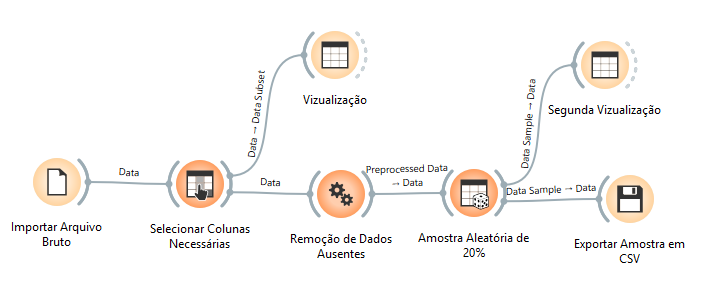

In [3]:
# Dataset 2 — Steel Industry Energy Consumption (UCI)

import pandas as pd

# 1. Carregar a base
df = pd.read_csv("/content/dataset2.csv")

# Renomear as colunas
df = df.rename(columns={
    "Usage_kWh": "Consumo_kWh",
    "Lagging_Current_Reactive.Power_kVarh": "Fator_Potencia_Atrasado",
    "Leading_Current_Reactive_Power_kVarh": "Fator_Potencia_Adiantado"
})

# 2. Inspeção inicial
print(df.head())
print(df.shape)
df.info()
print(df.describe())

# 3. Maior consumo e limiar de 75%
maior_consumo = df["Consumo_kWh"].max()
limiar = 0.75 * maior_consumo

print("Maior consumo:", maior_consumo)
print("Limiar:", limiar)

# 4. DataFrame com consumo elevado
df_consumo_alto = df[
    df["Consumo_kWh"] > limiar
]

quantidade = len(df_consumo_alto)
percentual = quantidade / len(df) * 100

print("Quantidade:", quantidade)
print("Percentual:", percentual)

# 5. Registros Maximum_Load
quantidade_maximum = (
    df_consumo_alto["Load_Type"] == "Maximum_Load"
).sum()

print("Maximum_Load:", quantidade_maximum)

# 6. Análise do fator de potência
print(df["Fator_Potencia_Atrasado"].describe())

limite_fator = 30

# 7. Aplicar os dois critérios
df_atencao = df[
    (df["Consumo_kWh"] > limiar) &
    (df["Fator_Potencia_Atrasado"] < limite_fator)
]

print(df_atencao)
print("Quantidade:", len(df_atencao))

from IPython.display import Image
Image('/content/20.png')

Primeiras linhas do dataset:


,DateTime,Temperature,Humidity,Wind Speed,Zone 1 Power Consumption,Zone 2 Power Consumption,Zone 3 Power Consumption
0,4/18/2017 16:20,22.76,29.73,0.085,32985.14532,19396.7,17623.3
1,12/27/2017 17:10,15.92,54.44,0.085,34737.64259,29803.0,14417.3
2,1/2/2017 11:20,15.08,57.23,0.076,27894.68354,20808.5,16458.8
3,3/19/2017 20:20,12.42,72.30,0.081,42476.93617,23634.1,25089.7
4,4/24/2017 5:50,14.58,80.60,0.080,21341.14101,12006.1,11531.6



Colunas após a renomeação:
['DateTime', 'Temperature', 'Humidity', 'Wind Speed', 'Consumo_Zona_1', 'Consumo_Zona_2', 'Consumo_Zona_3']

Consumo máximo registrado:
Zona 1: 51571.50
Zona 2: 36437.20
Zona 3: 47441.70

Zona com maior pico de consumo:
Consumo_Zona_1
Valor máximo: 51571.50

Limiar de 70% do maior consumo:
36100.05

DataFrame com registros acima do limiar:


,DateTime,Temperature,Humidity,Wind Speed,Consumo_Zona_1,Consumo_Zona_2,Consumo_Zona_3
3,3/19/2017 20:20,12.42,72.30,0.081,42476.93617,23634.1,25089.7
8,12/10/2017 17:50,14.66,65.92,0.075,37286.69202,30716.2,15834.8
12,6/5/2017 23:30,21.03,86.50,0.068,40993.90728,25383.4,24960.0
14,8/23/2017 17:50,27.06,47.58,4.905,37475.16093,24276.2,25140.6
19,6/22/2017 2:40,19.20,65.81,4.924,40676.02649,24754.7,25095.9



Quantidade de registros:
Total de registros: 7863
Registros acima do limiar: 2388
Percentual: 30.37%

Temperatura média:
18.79 °C

Segundo DataFrame:


,DateTime,Temperature,Humidity,Wind Speed,Consumo_Zona_1,Consumo_Zona_2,Consumo_Zona_3
12,6/5/2017 23:30,21.03,86.50,0.068,40993.90728,25383.4,24960.0
14,8/23/2017 17:50,27.06,47.58,4.905,37475.16093,24276.2,25140.6
19,6/22/2017 2:40,19.20,65.81,4.924,40676.02649,24754.7,25095.9
21,8/23/2017 13:50,27.11,43.35,4.906,40256.07103,27416.3,25453.5
25,7/12/2017 9:50,26.92,70.20,4.909,36511.89369,25906.3,25654.9



Após incluir a condição de temperatura:
Registros: 1597
Percentual: 20.31%

========== COMPARAÇÃO ==========
Registros apenas acima do limiar: 2388
Registros acima do limiar + temperatura acima da média: 1597

Quantidade de registros eliminados pela nova condição: 791
Redução percentual dentro do primeiro conjunto: 33.12%

Conclusão:
Ao adicionar a condição de temperatura acima da média, a quantidade de registros diminuiu, pois agora o registro precisa atender simultaneamente às duas condições: consumo acima de 70% do pico e temperatura acima da média.


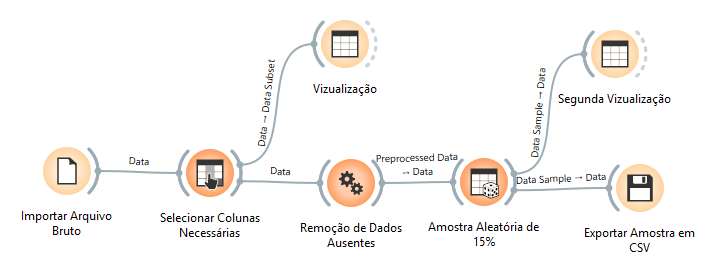

In [4]:
# Dataset 3 — Power Consumption of Tetouan City (UCI)

import pandas as pd

# 1. Carregar Dataset
df = pd.read_csv("/content/dataset3.csv")

# Visualizar as primeiras linhas
print("Primeiras linhas do dataset:")
display(df.head())

# 2. Renomear as variáveis de consumo

df = df.rename(columns={
    "Zone 1 Power Consumption": "Consumo_Zona_1",
    "Zone 2  Power Consumption": "Consumo_Zona_2",
    "Zone 3  Power Consumption": "Consumo_Zona_3"
})

print("\nColunas após a renomeação:")
print(df.columns.tolist())

# 3. Determinar o consumo máximo de cada zona

max_zona_1 = df["Consumo_Zona_1"].max()
max_zona_2 = df["Consumo_Zona_2"].max()
max_zona_3 = df["Consumo_Zona_3"].max()

print("\nConsumo máximo registrado:")
print(f"Zona 1: {max_zona_1:.2f}")
print(f"Zona 2: {max_zona_2:.2f}")
print(f"Zona 3: {max_zona_3:.2f}")

# 4. Identificar a zona com maior consumo

maximos = {
    "Consumo_Zona_1": max_zona_1,
    "Consumo_Zona_2": max_zona_2,
    "Consumo_Zona_3": max_zona_3
}

zona_maior_pico = max(maximos, key=maximos.get)
maior_pico = maximos[zona_maior_pico]

print("\nZona com maior pico de consumo:")
print(zona_maior_pico)
print(f"Valor máximo: {maior_pico:.2f}")


# 5. Calcular 70% do máximo e criar dayaframe com os registros a cima do limiar
limiar = 0.70 * maior_pico

df_acima_limiar = df[df[zona_maior_pico] > limiar].copy()

print("\nLimiar de 70% do maior consumo:")
print(f"{limiar:.2f}")

print("\nDataFrame com registros acima do limiar:")
display(df_acima_limiar.head())

# 6. Contar os registros e calcular o percentual

total_registros = len(df)
registros_acima = len(df_acima_limiar)

percentual_acima = (registros_acima / total_registros) * 100

print("\nQuantidade de registros:")
print(f"Total de registros: {total_registros}")
print(f"Registros acima do limiar: {registros_acima}")
print(f"Percentual: {percentual_acima:.2f}%")

# 7. Calcular a temperatura média

temperatura_media = df["Temperature"].mean()

print("\nTemperatura média:")
print(f"{temperatura_media:.2f} °C")



# 8. Criar segundo dataframe
# Consumo acima do limiar e temperatura acima da média

df_acima_limiar_temp = df[
    (df[zona_maior_pico] > limiar) &
    (df["Temperature"] > temperatura_media)
].copy()

print("\nSegundo DataFrame:")
display(df_acima_limiar_temp.head())

# 9. Contar os registros do segundo dataframe

registros_com_condicao_ambiental = len(df_acima_limiar_temp)

percentual_com_condicao_ambiental = (
    registros_com_condicao_ambiental / total_registros
) * 100

print("\nApós incluir a condição de temperatura:")
print(f"Registros: {registros_com_condicao_ambiental}")
print(f"Percentual: {percentual_com_condicao_ambiental:.2f}%")

# 10. Comparação dos dois dataframes juntos

reducao_registros = registros_acima - registros_com_condicao_ambiental

percentual_reducao = (
    reducao_registros / registros_acima
) * 100

print("\n========== COMPARAÇÃO ==========")

print(f"Registros apenas acima do limiar: {registros_acima}")
print(f"Registros acima do limiar + temperatura acima da média: "
      f"{registros_com_condicao_ambiental}")

print(f"\nQuantidade de registros eliminados pela nova condição: "
      f"{reducao_registros}")

print(f"Redução percentual dentro do primeiro conjunto: "
      f"{percentual_reducao:.2f}%")

print("\nConclusão:")
print(
    "Ao adicionar a condição de temperatura acima da média, "
    "a quantidade de registros diminuiu, pois agora o registro "
    "precisa atender simultaneamente às duas condições: "
    "consumo acima de 70% do pico e temperatura acima da média."
)

from IPython.display import Image
Image('/content/15.png')

Colunas após renomeação:
['DATE_TIME', 'SOURCE_KEY', 'Potencia_CC', 'Potencia_CA', 'Geracao_Diaria', 'TOTAL_YIELD']

===== HEAD =====


,DATE_TIME,SOURCE_KEY,Potencia_CC,Potencia_CA,Geracao_Diaria,TOTAL_YIELD
0,2020-05-28 10:00:00,vOuJvMaM2sgwLmb,1090.240,1063.560,2079.21,2.307960e+06
1,2020-06-16 11:15:00,81aHJ1q11NBPMrL,740.613,724.827,2209.60,1.215480e+09
2,2020-05-17 18:45:00,Qf4GUc1pJu5T6c6,0.000,0.000,7220.00,8.384430e+08
3,2020-05-21 23:00:00,q49J1IKaHRwDQnt,0.000,0.000,4844.00,3.741710e+05
4,2020-06-05 23:15:00,vOuJvMaM2sgwLmb,0.000,0.000,3421.00,2.356530e+06


(10155, 6)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10155 entries, 0 to 10154
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   DATE_TIME       10155 non-null  object 
 1   SOURCE_KEY      10155 non-null  object 
 2   Potencia_CC     10155 non-null  float64
 3   Potencia_CA     10155 non-null  float64
 4   Geracao_Diaria  10155 non-null  float64
 5   TOTAL_YIELD     10155 non-null  float64
dtypes: float64(4), object(2)
memory usage: 476.1+ KB


,Potencia_CC,Potencia_CA,Geracao_Diaria,TOTAL_YIELD
count,10155.000000,10155.000000,10155.000000,1.015500e+04
mean,243.987889,238.624750,3315.640563,6.447321e+08
std,368.762444,360.342998,2923.227260,7.187998e+08
min,0.000000,0.000000,0.000000,0.000000e+00
25%,0.000000,0.000000,294.902000,1.996630e+07
50%,0.000000,0.000000,2982.800000,2.826080e+08
75%,442.330000,433.993500,5556.000000,1.348460e+09
max,1401.310000,1366.260000,9873.000000,2.247920e+09



===== MAIOR POTÊNCIA CA =====
1366.26

===== LIMIAR (70% DA POTÊNCIA CA MÁXIMA) =====
956.38

===== REGISTROS ACIMA DO LIMIAR =====
Quantidade: 760
Percentual: 7.48%


,DATE_TIME,SOURCE_KEY,Potencia_CC,Potencia_CA,Geracao_Diaria,TOTAL_YIELD
0,2020-05-28 10:00:00,vOuJvMaM2sgwLmb,1090.240,1063.560,2079.21,2.307960e+06
28,2020-05-25 13:15:00,V94E5Ben1TlhnDV,1214.840,1184.460,5807.29,1.412160e+09
36,2020-05-25 12:15:00,WcxssY2VbP4hApt,1293.090,1260.780,4649.40,1.817800e+08
40,2020-05-29 12:30:00,Qf4GUc1pJu5T6c6,995.821,973.700,4488.86,8.385320e+08
59,2020-05-18 14:45:00,IQ2d7wF4YD8zU1Q,996.420,974.307,6351.07,1.997270e+07



===== FREQUÊNCIA DOS INVERSORES =====
SOURCE_KEY
oZ35aAeoifZaQzV    52
Mx2yZCDsyf6DPfv    51
oZZkBaNadn6DNKz    47
Qf4GUc1pJu5T6c6    47
V94E5Ben1TlhnDV    47
4UPUqMRk7TRMgml    45
WcxssY2VbP4hApt    44
81aHJ1q11NBPMrL    41
vOuJvMaM2sgwLmb    38
mqwcsP2rE7J0TFp    37
xoJJ8DcxJEcupym    37
PeE6FRyGXUgsRhN    37
LlT2YUhhzqhg5Sw    37
9kRcWv60rDACzjR    36
IQ2d7wF4YD8zU1Q    34
xMbIugepa2P7lBB    33
NgDl19wMapZy17u    23
q49J1IKaHRwDQnt    23
rrq4fwE8jgrTyWY    19
Et9kgGMDl729KT4    17
LYwnQax7tkwH5Cb    11
Quc1TzYxW2pYoWX     4
Name: count, dtype: int64


,count
SOURCE_KEY,
oZ35aAeoifZaQzV,52
Mx2yZCDsyf6DPfv,51
oZZkBaNadn6DNKz,47
Qf4GUc1pJu5T6c6,47
V94E5Ben1TlhnDV,47
4UPUqMRk7TRMgml,45
WcxssY2VbP4hApt,44
81aHJ1q11NBPMrL,41
vOuJvMaM2sgwLmb,38



===== INVERSOR MAIS FREQUENTE =====
Inversor: oZ35aAeoifZaQzV
Ocorrências: 52

INTERPRETAÇÃO:
O inversor identificado aparece com maior frequência entre os registros classificados como de alta geração (acima de 70% da potência CA máxima observada). Esse resultado indica apenas que ele esteve mais presente nesse subconjunto específico de registros. Entretanto, esse recorte isolado não é suficiente para concluir que o equipamento possui melhor desempenho ou apresenta falhas, pois seriam necessárias análises complementares, como tempo de operação, distribuição dos registros, potência média, eficiência e comparação com os demais inversores ao longo de todo o período analisado.


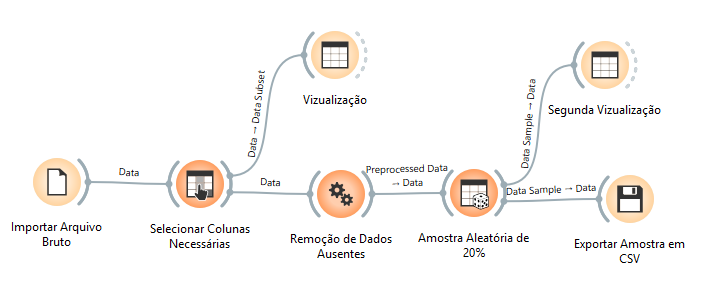

In [5]:
# Dataset 4 — Solar Power Generation Data (Kaggle)

import pandas as pd

# 1. Carregar a amostra e renomear as variáveis

df = pd.read_csv("/content/dataset4.csv")

df = df.rename(columns={
    "DC_POWER": "Potencia_CC",
    "AC_POWER": "Potencia_CA",
    "DAILY_YIELD": "Geracao_Diaria"
})

print("Colunas após renomeação:")
print(df.columns.tolist())

# 2. Apresentação head(), shape, info() e describe()

print("\n===== HEAD =====")
display(df.head())
print(df.shape)
df.info()
display(df.describe())

# 3. Maior potência CA registrada

potencia_ca_max = df["Potencia_CA"].max()

print("\n===== MAIOR POTÊNCIA CA =====")
print(f"{potencia_ca_max:.2f}")

# 4. Limiar correspondente a 70% da potência CA máxima

limiar = potencia_ca_max * 0.70

print("\n===== LIMIAR (70% DA POTÊNCIA CA MÁXIMA) =====")
print(f"{limiar:.2f}")

# 5. Dataframe com registros acima do limiar

df_alta_geracao = df[df["Potencia_CA"] > limiar].copy()

quantidade = len(df_alta_geracao)
total = len(df)

percentual = (quantidade / total) * 100

print("\n===== REGISTROS ACIMA DO LIMIAR =====")
print(f"Quantidade: {quantidade}")
print(f"Percentual: {percentual:.2f}%")

display(df_alta_geracao.head())

# 6. value_counts() em SOURCE_KEY

print("\n===== FREQUÊNCIA DOS INVERSORES =====")

frequencia_inversores = df_alta_geracao["SOURCE_KEY"].value_counts()

print(frequencia_inversores)

display(frequencia_inversores)

# 7. Invensor mais frequênte

inversor_mais_frequente = frequencia_inversores.idxmax()
ocorrencias = frequencia_inversores.max()

print("\n===== INVERSOR MAIS FREQUENTE =====")
print(f"Inversor: {inversor_mais_frequente}")
print(f"Ocorrências: {ocorrencias}")

print("\nINTERPRETAÇÃO:")
print(
    "O inversor identificado aparece com maior frequência entre os "
    "registros classificados como de alta geração (acima de 70% da "
    "potência CA máxima observada). Esse resultado indica apenas que "
    "ele esteve mais presente nesse subconjunto específico de registros. "
    "Entretanto, esse recorte isolado não é suficiente para concluir que "
    "o equipamento possui melhor desempenho ou apresenta falhas, pois "
    "seriam necessárias análises complementares, como tempo de operação, "
    "distribuição dos registros, potência média, eficiência e comparação "
    "com os demais inversores ao longo de todo o período analisado."
)

from IPython.display import Image
Image('/content/20.png')

Dados originais:


,Date,Source,Production,Start_Hour,End_Hour,Day_of_Year
0,12/18/2022,Wind,11400,21,22,352
1,1/29/2024,Wind,7917,14,15,29
2,8/1/2024,Solar,8835,15,16,214
3,11/10/2020,Wind,989,1,2,315
4,12/19/2022,Wind,12526,1,2,353



DataFrame com as novas variáveis:


,Date,Source,Production,Start_Hour,End_Hour,Day_of_Year,Geracao_Solar,Geracao_Eolica
0,12/18/2022,Wind,11400,21,22,352,0,11400
1,1/29/2024,Wind,7917,14,15,29,0,7917
2,8/1/2024,Solar,8835,15,16,214,8835,0
3,11/10/2020,Wind,989,1,2,315,0,989
4,12/19/2022,Wind,12526,1,2,353,0,12526



Valores máximos registrados:
Máximo de geração solar: 16316
Máximo de geração eólica: 22929

Limiares de 70%:
70% do máximo solar: 11421.20
70% do máximo eólico: 16050.30

DataFrame de alta geração solar:


,Date,Source,Production,Start_Hour,End_Hour,Day_of_Year,Geracao_Solar,Geracao_Eolica
77,7/8/2025,Solar,13125,13,14,189,13125,0
178,3/19/2025,Solar,13786,13,14,78,13786,0
183,8/17/2025,Solar,11455,12,13,229,11455,0
187,7/16/2025,Solar,16160,12,13,197,16160,0
207,3/31/2025,Solar,12441,12,13,90,12441,0



DataFrame de alta geração eólica:


,Date,Source,Production,Start_Hour,End_Hour,Day_of_Year,Geracao_Solar,Geracao_Eolica
20,1/3/2024,Wind,17272,0,1,3,0,17272
32,3/11/2021,Wind,16144,13,14,70,0,16144
103,1/29/2025,Wind,18199,0,1,29,0,18199
151,12/8/2024,Wind,16946,6,7,343,0,16946
192,11/19/2024,Wind,16568,2,3,324,0,16568



========== RESULTADOS ==========
Total de registros: 10373

Alta geração solar:
Quantidade: 45
Percentual: 0.43%

Alta geração eólica:
Quantidade: 245
Percentual: 2.36%

========== COMPARAÇÃO ==========
A geração eólica aparece com maior frequência acima de 70% do seu próprio máximo.

Comparação percentual:
Solar: 0.43%
Eólica: 2.36%

========== EXPLICAÇÃO ==========
Não é adequado utilizar diretamente o mesmo valor numérico de potência como limite para as duas fontes porque a geração solar e a geração eólica podem apresentar escalas e valores máximos diferentes. Por isso, foi utilizado um limite relativo de 70% do máximo de cada fonte. Dessa forma, cada fonte é analisada de acordo com sua própria escala, permitindo uma comparação mais justa da frequência de registros de alta geração.


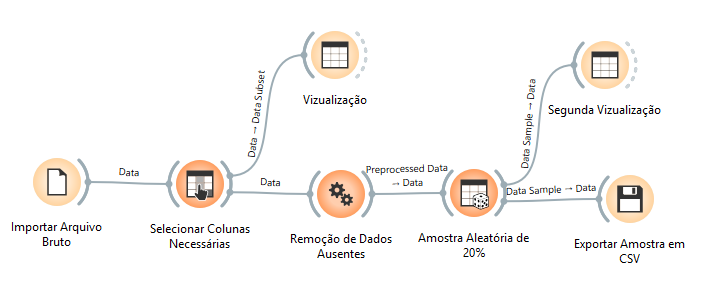

In [6]:
# Dataset 5 — Wind & Solar Energy Production (Kaggle)

import pandas as pd

# 1. Carregar amostra

df = pd.read_csv("dataset5.csv")

print("Dados originais:")
display(df.head())

# 2. Renomear as variáveis principais
# Criar as colunas de geração solar e eólica

df["Geracao_Solar"] = df["Production"].where(
    df["Source"] == "Solar", 0
)

df["Geracao_Eolica"] = df["Production"].where(
    df["Source"] == "Wind", 0
)

print("\nDataFrame com as novas variáveis:")
display(df.head())

# 3. Determinar o valor máximo de cada fonte

max_solar = df["Geracao_Solar"].max()
max_eolica = df["Geracao_Eolica"].max()

print("\nValores máximos registrados:")
print(f"Máximo de geração solar: {max_solar}")
print(f"Máximo de geração eólica: {max_eolica}")

# 4. Calcular 70% dos máximos

limiar_solar = max_solar * 0.70
limiar_eolica = max_eolica * 0.70

print("\nLimiares de 70%:")
print(f"70% do máximo solar: {limiar_solar:.2f}")
print(f"70% do máximo eólico: {limiar_eolica:.2f}")

# 5. Criar dataframe de alta geração solar

df_alta_solar = df[
    df["Geracao_Solar"] > limiar_solar
].copy()

print("\nDataFrame de alta geração solar:")
display(df_alta_solar.head())

# 6. Criar dataframe de alta geração eólica

df_alta_eolica = df[
    df["Geracao_Eolica"] > limiar_eolica
].copy()

print("\nDataFrame de alta geração eólica:")
display(df_alta_eolica.head())

# 7. Contar os registros e calcular os percentuais

total_registros = len(df)

quantidade_solar = len(df_alta_solar)
quantidade_eolica = len(df_alta_eolica)

percentual_solar = (quantidade_solar / total_registros) * 100
percentual_eolica = (quantidade_eolica / total_registros) * 100

print("\n========== RESULTADOS ==========")

print(f"Total de registros: {total_registros}")

print("\nAlta geração solar:")
print(f"Quantidade: {quantidade_solar}")
print(f"Percentual: {percentual_solar:.2f}%")

print("\nAlta geração eólica:")
print(f"Quantidade: {quantidade_eolica}")
print(f"Percentual: {percentual_eolica:.2f}%")

# 8. Comparar as duas fontes

print("\n========== COMPARAÇÃO ==========")

if quantidade_solar > quantidade_eolica:
    print("A geração solar aparece com maior frequência acima de 70% do seu próprio máximo.")

elif quantidade_eolica > quantidade_solar:
    print("A geração eólica aparece com maior frequência acima de 70% do seu próprio máximo.")

else:
    print("As duas fontes apresentam a mesma frequência acima de 70% dos seus respectivos máximos.")

# 9. Comparação dos percentuais

print("\nComparação percentual:")
print(f"Solar: {percentual_solar:.2f}%")
print(f"Eólica: {percentual_eolica:.2f}%")

# 10. Explicação sobre os limites

print("\n========== EXPLICAÇÃO ==========")

print(
    "Não é adequado utilizar diretamente o mesmo valor numérico de potência "
    "como limite para as duas fontes porque a geração solar e a geração eólica "
    "podem apresentar escalas e valores máximos diferentes. "
    "Por isso, foi utilizado um limite relativo de 70% do máximo de cada fonte. "
    "Dessa forma, cada fonte é analisada de acordo com sua própria escala, "
    "permitindo uma comparação mais justa da frequência de registros de alta geração."
)

from IPython.display import Image
Image('/content/20.png')

Colunas do DataFrame:
['Date', 'Potencia_Ativa', 'Potencia_Reativa', 'Voltage', 'Corrente', 'Consumo_1', 'Consumo_2', 'Consumo_3']

Primeiras linhas:


,Date,Potencia_Ativa,Potencia_Reativa,Voltage,Corrente,Consumo_1,Consumo_2,Consumo_3
0,2/4/2008,0.288,0.000,240.17,1.2,0.0,1.0,0.0
1,12/11/2007,1.360,0.056,239.77,5.6,0.0,0.0,18.0
2,4/8/2007,0.310,0.100,237.68,1.4,0.0,0.0,0.0
3,1/9/2007,1.810,0.368,242.45,7.6,0.0,2.0,0.0
4,18/11/2007,1.932,0.480,245.56,8.0,1.0,1.0,19.0



Maior valor de potência ativa:
10.162

Limiar de 75% da potência máxima:
7.622

Primeiros registros acima do limite:


,Date,Potencia_Ativa,Potencia_Reativa,Voltage,Corrente,Consumo_1,Consumo_2,Consumo_3
1579,5/3/2008,7.890,0.000,232.62,33.8,36.0,35.0,17.0
6008,9/12/2007,8.020,0.478,236.69,33.8,75.0,5.0,17.0
6724,29/11/2008,8.114,0.000,235.09,34.4,0.0,0.0,17.0
6942,23/10/2007,8.058,0.108,235.34,34.2,37.0,72.0,17.0
8378,13/1/2007,7.904,0.000,230.55,34.4,72.0,0.0,16.0



========== REGISTROS ACIMA DE 75% ==========
Total de registros: 208902
Registros selecionados: 113
Percentual: 0.05%

Corrente média da amostra:
4.721

========== SEGUNDO DATAFRAME ==========
Registros com potência acima de 75% do máximo
E corrente acima da média:


,Date,Potencia_Ativa,Potencia_Reativa,Voltage,Corrente,Consumo_1,Consumo_2,Consumo_3
1579,5/3/2008,7.890,0.000,232.62,33.8,36.0,35.0,17.0
6008,9/12/2007,8.020,0.478,236.69,33.8,75.0,5.0,17.0
6724,29/11/2008,8.114,0.000,235.09,34.4,0.0,0.0,17.0
6942,23/10/2007,8.058,0.108,235.34,34.2,37.0,72.0,17.0
8378,13/1/2007,7.904,0.000,230.55,34.4,72.0,0.0,16.0



========== COMPARAÇÃO ==========
Conjunto 1 - Potência acima de 75%:
Quantidade: 113
Percentual do total: 0.05%

Conjunto 2 - Potência acima de 75% + Corrente acima da média:
Quantidade: 113
Percentual do total: 0.05%

Registros removidos pela segunda condição:
0

Redução dentro do primeiro conjunto: 0.00%

========== CONCLUSÃO ==========
A inclusão da corrente acima da média tornou o filtro mais restritivo. No primeiro conjunto, eram considerados todos os registros com potência ativa acima de 75% do valor máximo. No segundo conjunto, além dessa condição, o registro também precisava apresentar corrente acima da média. Por isso, a quantidade de registros selecionados diminuiu. Isso mostra que nem todos os registros de alta potência possuem simultaneamente corrente acima da média da amostra.


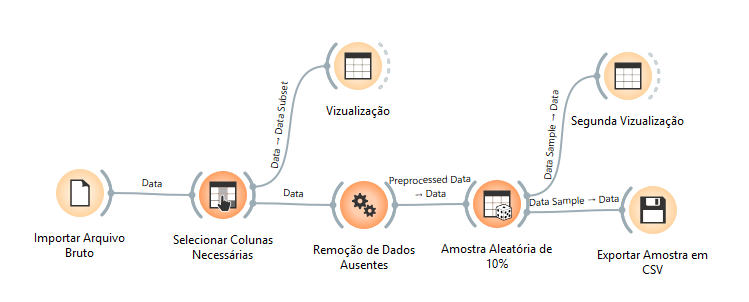

In [7]:
# Dataset 6 — Individual Household Electric Power Consumption (UCI)

import pandas as pd

# 1. Carregar a amostra e organizar os atributos

df = pd.read_csv("/content/dataset6.csv")

# Renomear as principais variáveis para nomes mais simples
df = df.rename(columns={
    "Global_active_power": "Potencia_Ativa",
    "Global_reactive_power": "Potencia_Reativa",
    "Global_intensity": "Corrente",
    "Sub_metering_1": "Consumo_1",
    "Sub_metering_2": "Consumo_2",
    "Sub_metering_3": "Consumo_3"
})

print("Colunas do DataFrame:")
print(df.columns.tolist())

print("\nPrimeiras linhas:")
display(df.head())

# 2. Determinar o valor máximo de potência ativa

max_potencia = df["Potencia_Ativa"].max()

print("\nMaior valor de potência ativa:")
print(f"{max_potencia:.3f}")

# 3. Calcular 75% do valor máximo
# e criar dataframe com os redistros acima do limite

limiar = max_potencia * 0.75

df_alta_potencia = df[
    df["Potencia_Ativa"] > limiar
].copy()

print("\nLimiar de 75% da potência máxima:")
print(f"{limiar:.3f}")

print("\nPrimeiros registros acima do limite:")
display(df_alta_potencia.head())

# 4. Contidade e percentual dos limites selecionados

total_registros = len(df)
quantidade_alta_potencia = len(df_alta_potencia)

percentual_alta_potencia = (
    quantidade_alta_potencia / total_registros
) * 100

print("\n========== REGISTROS ACIMA DE 75% ==========")
print(f"Total de registros: {total_registros}")
print(f"Registros selecionados: {quantidade_alta_potencia}")
print(f"Percentual: {percentual_alta_potencia:.2f}%")

# 5. Calcular a corrente média da amostra

corrente_media = df["Corrente"].mean()

print("\nCorrente média da amostra:")
print(f"{corrente_media:.3f}")

# 6. Criar segundo dataframe
# Potência acima de 75% e corrente acima da média

df_alta_potencia_corrente = df[
    (df["Potencia_Ativa"] > limiar) &
    (df["Corrente"] > corrente_media)
].copy()

print("\n========== SEGUNDO DATAFRAME ==========")
print("Registros com potência acima de 75% do máximo")
print("E corrente acima da média:")

display(df_alta_potencia_corrente.head())

# 7. Comparar os dois conjuntos

quantidade_segundo = len(df_alta_potencia_corrente)

percentual_segundo = (
    quantidade_segundo / total_registros
) * 100

reducao = quantidade_alta_potencia - quantidade_segundo

if quantidade_alta_potencia > 0:
    percentual_reducao = (
        reducao / quantidade_alta_potencia
    ) * 100
else:
    percentual_reducao = 0

print("\n========== COMPARAÇÃO ==========")

print(f"Conjunto 1 - Potência acima de 75%:")
print(f"Quantidade: {quantidade_alta_potencia}")
print(f"Percentual do total: {percentual_alta_potencia:.2f}%")

print("\nConjunto 2 - Potência acima de 75% + Corrente acima da média:")
print(f"Quantidade: {quantidade_segundo}")
print(f"Percentual do total: {percentual_segundo:.2f}%")

print("\nRegistros removidos pela segunda condição:")
print(f"{reducao}")

print(f"\nRedução dentro do primeiro conjunto: "
      f"{percentual_reducao:.2f}%")

# 8. Explicação do efeito da segundo condição

print("\n========== CONCLUSÃO ==========")

print(
    "A inclusão da corrente acima da média tornou o filtro mais restritivo. "
    "No primeiro conjunto, eram considerados todos os registros com potência "
    "ativa acima de 75% do valor máximo. No segundo conjunto, além dessa "
    "condição, o registro também precisava apresentar corrente acima da média. "
    "Por isso, a quantidade de registros selecionados diminuiu. "
    "Isso mostra que nem todos os registros de alta potência possuem "
    "simultaneamente corrente acima da média da amostra."
)

from IPython.display import Image
Image('/content/10.png')